# Lowest-Price Home Insurance Quote Estimator

**Author:** Samuel · **Date:** 2026-05-16
**Dataset:** `UJ_datatask_prices.csv` - 385,025 quote rows from a 7-insurer panel for Home Insurance.

## Objective
Build a model that, given a subset of customer / property *input* circumstances, predicts the **lowest** `TotalAmountPayable` a panel of insurers would offer for that QuoteID - regardless of insurer or payment method.

## Notebook structure

1. Environment & reproducibility
2. Data loading
3. **Data quality analysis** - nulls, duplicates, dtypes, memory
4. Structural EDA - quotes-per-QuoteID, panel coverage
5. **Target deep dive** - distribution, skew, log-test, outliers
6. Input-feature triage - varying vs fixed; the 6-feature insight
7. Target construction - collapse to one row per QuoteID
8. **Univariate + bivariate EDA** - Spearman correlation, interactions
9. Feature engineering - outward postcode added
10. Train / test protocol - random split **+** GroupKFold by postcode + by occupation
11. Models - Baseline → Ridge → Random Forest → HistGradientBoosting
12. **Hyperparameter tuning** - `RandomizedSearchCV` on HGB
13. Diagnostics - residuals, permutation importance, **SHAP**, segment error
14. **Quantile regression** - prediction intervals
15. **Productionisation** - `joblib` bundle + `predict_lowest_price()` + worked examples
16. Discussion, limitations, next steps

## 1. Environment & reproducibility

This block makes the notebook **fully portable** - it runs unchanged in:

1. **Local Jupyter / VS Code** - place the CSV next to the notebook and run all cells.
2. **Google Colab** - upload the CSV (and the notebook) via the Files panel in the left sidebar; no Drive mount required.
3. **Google Colab + Drive** - optional fallback if you keep the CSV on your Drive.

No paths need to be edited by the runner. All paths use `pathlib`. A `requirements.txt`
is shipped alongside the notebook with pinned versions matching the printed output below.


In [ ]:
import os, sys, platform, warnings, json, time, re, subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn import set_config
set_config(transform_output='pandas')

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# ── Pinned randomness for every estimator below ────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({
    'figure.dpi'        : 110,
    'savefig.dpi'       : 200,
    'figure.figsize'    : (10, 5),
    'axes.titleweight'  : 'bold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# ── Portable environment detection (no Drive mount required) ───────────────
DATA_FILENAME = 'UJ_datatask_prices.csv'

def _try_locations():
    """Yield candidate base directories in priority order."""
    yield ('cwd', Path.cwd())
    try:
        yield ('notebook_dir', Path(__file__).parent)  # type: ignore[name-defined]
    except NameError:
        pass
    if Path('/content').exists():
        yield ('colab_content', Path('/content'))

def _find_csv():
    for tag, candidate in _try_locations():
        if (candidate / DATA_FILENAME).exists():
            return candidate
    return None

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

def detect_environment():
    """Auto-detect runtime; return (env_name, base_dir).
    In Colab, prompts for upload if the CSV is missing; never silently mounts Drive."""
    in_colab = _in_colab()
    env = 'colab' if in_colab else 'local'

    base = _find_csv()
    if base is not None:
        return env, base

    # Colab + opt-in Drive fallback
    if in_colab and os.environ.get('UJ_USE_DRIVE', '0') == '1':
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
            for sub in ['Urban Jungle Task', 'Urabn Jungle Task']:
                p = Path('/content/drive/MyDrive') / sub
                if (p / DATA_FILENAME).exists():
                    return 'colab', p
        except Exception as e:
            print(f'[warn] Drive mount failed: {e}')

    # Colab: prompt for in-cell upload
    if in_colab:
        print(f'[setup] {DATA_FILENAME} not found in /content/. Please upload it now...')
        try:
            from google.colab import files
            uploaded = files.upload()   # opens a file picker in the notebook
            if DATA_FILENAME not in uploaded:
                # User may have uploaded with a different name; find any *.csv that matches
                for name in uploaded.keys():
                    if name.lower().endswith('.csv'):
                        src = Path('/content') / name
                        dst = Path('/content') / DATA_FILENAME
                        if src != dst:
                            src.replace(dst)
                        break
            if (Path('/content') / DATA_FILENAME).exists():
                return 'colab', Path('/content')
        except Exception as e:
            print(f'[warn] in-cell upload failed: {e}')

    return env, Path.cwd()

ENV, BASE_DIR = detect_environment()
DATA_PATH     = BASE_DIR / DATA_FILENAME
PLOTS_DIR     = BASE_DIR / 'plots'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    out = PLOTS_DIR / f'{name}.png'
    try:
        plt.savefig(out, dpi=200, bbox_inches='tight')
    except Exception as e:
        print(f'[warn] could not save {out}: {e}')
    return out

print(f'Environment    : {ENV}')
print(f'Base dir       : {BASE_DIR}')
print(f'Data file      : {DATA_PATH}  {"OK" if DATA_PATH.exists() else "NOT FOUND"}')
print(f'Plots dir      : {PLOTS_DIR}')
print(f'Artifacts dir  : {ARTIFACTS_DIR}')

if not DATA_PATH.exists():
    print()
    print('=' * 70)
    print('DATA FILE NOT FOUND')
    print('=' * 70)
    print(f'Expected: {DATA_PATH}')
    print()
    print('To fix:')
    print('  - Local Jupyter: place UJ_datatask_prices.csv next to this notebook.')
    print('  - Colab        : re-run this cell and choose the CSV in the upload dialog.')
    print('  - Colab + Drive: set os.environ["UJ_USE_DRIVE"]="1" before this cell,')
    print('                   keep the CSV in MyDrive/Urban Jungle Task/.')
    raise FileNotFoundError(str(DATA_PATH))

print()
print('─── versions ───────────────────────────────────────────')
print(f'Platform   : {platform.platform()}')
print(f'Python     : {sys.version.split()[0]}')
print(f'numpy      : {np.__version__}')
print(f'pandas     : {pd.__version__}')
print(f'scipy      : {scipy.__version__}')
print(f'sklearn    : {sklearn.__version__}')
print(f'matplotlib : {plt.matplotlib.__version__}')
print(f'seaborn    : {sns.__version__}')
print(f'joblib     : {joblib.__version__}')
print(f'Random seed: {RANDOM_STATE}')


## 2. Load the raw data

385,025 rows × 67 columns. We read once and keep the original frame immutable; all derived frames are explicit.

In [2]:
t0 = time.time()
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns in {time.time()-t0:.1f}s')
print(f'Memory footprint: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_raw.head(3)

Loaded 385,025 rows × 67 columns in 8.3s
Memory footprint: 550.5 MB


,ID,QUOTEID,Insurer,Product,PaymentMethod,PaymentFrequency,TotalCostPerPaymentPeriod,TotalPremiumIncludingIPT,TotalPremiumExcludingIPT,AdministrationChargeIncludingIPT,...,HOMEEMERGENCY,CREDITREPORT,PERMOCCUPIED,SUBSIDENCE,CONVICTIONS,INSURANCEDECLINES,FLOODING,UNOCCUPIED60,BUSINESSPURPOSES,UNMORTGAGEAPP
0,1,1,A,Home Insurance,DirectDebit,Annual,114.92,114.92,104.47,39.6,...,False,True,True,False,False,False,False,False,False,False
1,2,1,A,Home Insurance,CreditCard,Annual,116.64,114.92,104.47,39.6,...,False,True,True,False,False,False,False,False,False,False
2,3,1,A,Home Insurance,DebitCard,Annual,114.92,114.92,104.47,39.6,...,False,True,True,False,False,False,False,False,False,False


## 3. Data quality analysis

Four standard checks before any modelling: **dtypes, nulls, duplicates, and memory**. The file has 67 columns but most will turn out to be either constants or output fields - we still inspect them all here so the audit trail is explicit.

In [3]:
quality = pd.DataFrame({
    'dtype'    : df_raw.dtypes.astype(str),
    'n_unique' : df_raw.nunique(dropna=False),
    'n_null'   : df_raw.isna().sum(),
    'pct_null' : (df_raw.isna().mean() * 100).round(3),
    'sample'   : [df_raw[c].dropna().unique()[:3].tolist() for c in df_raw.columns],
})
print('=== Per-column data quality (first 20) ===')
print(quality.head(20).to_string())

print(f'\nTotal null cells       : {df_raw.isna().sum().sum():,}')
print(f'Columns with any null  : {(df_raw.isna().sum() > 0).sum()}')
print(f'Duplicate rows         : {df_raw.duplicated().sum():,}')
print(f'Duplicate IDs          : {df_raw["ID"].duplicated().sum():,}')
print(f'Constant columns       : {(quality["n_unique"] == 1).sum()}')
print(f'Binary columns         : {(quality["n_unique"] == 2).sum()}')
print(f'Categorical (3-30)     : {((quality["n_unique"] >= 3) & (quality["n_unique"] <= 30)).sum()}')
print(f'High-cardinality (>30) : {(quality["n_unique"] > 30).sum()}')

=== Per-column data quality (first 20) ===
                                                 dtype  n_unique  n_null  pct_null                                 sample
ID                                               int64    385025       0       0.0                              [1, 2, 3]
QUOTEID                                          int64     18720       0       0.0                              [1, 2, 3]
Insurer                                         object         7       0       0.0                              [A, B, C]
Product                                         object         1       0       0.0                       [Home Insurance]
PaymentMethod                                   object         3       0       0.0   [DirectDebit, CreditCard, DebitCard]
PaymentFrequency                                object         3       0       0.0  [Annual, Monthly2MonthsFree, Monthly]
TotalCostPerPaymentPeriod                      float64     12871       0       0.0                [114.

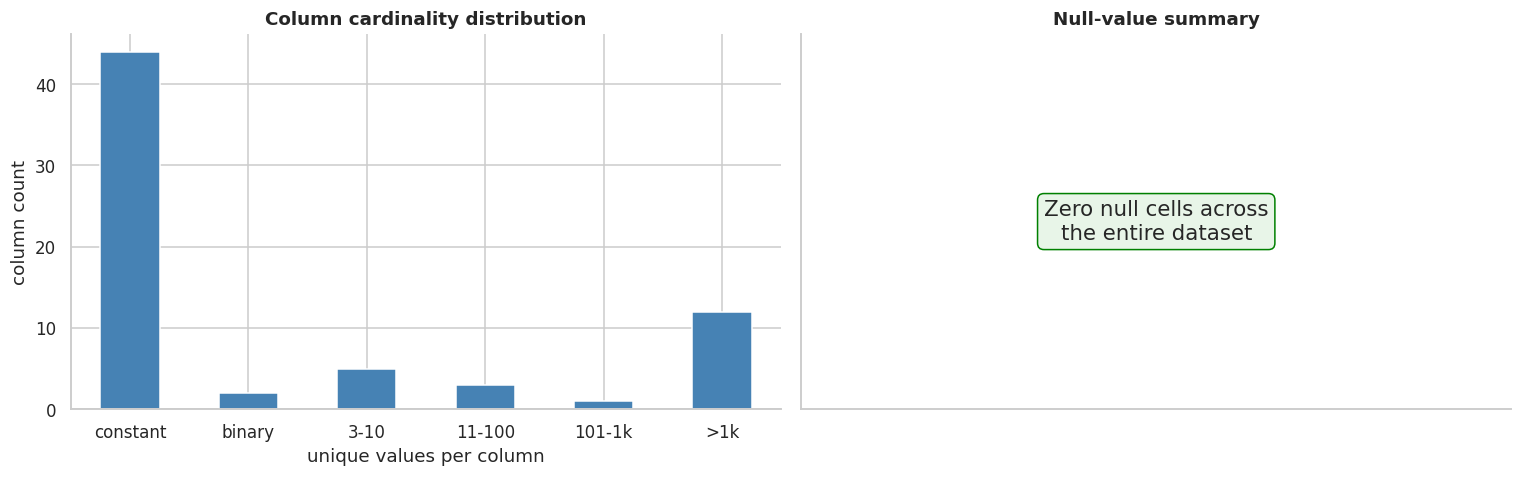

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

cardinality_bins = pd.cut(quality['n_unique'],
                          bins=[0, 1, 2, 10, 100, 1_000, 10_000_000],
                          labels=['constant', 'binary', '3-10', '11-100', '101-1k', '>1k'])
cardinality_bins.value_counts().sort_index().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Column cardinality distribution')
axes[0].set_xlabel('unique values per column')
axes[0].set_ylabel('column count')
axes[0].tick_params(axis='x', rotation=0)

null_counts = df_raw.isna().sum()
if null_counts.sum() == 0:
    axes[1].text(0.5, 0.5, 'Zero null cells across\nthe entire dataset',
                 ha='center', va='center', fontsize=14,
                 transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='#e8f5e8', edgecolor='green'))
    axes[1].set_title('Null-value summary')
    axes[1].set_xticks([]); axes[1].set_yticks([])
else:
    null_counts[null_counts > 0].plot.bar(ax=axes[1], color='crimson')
    axes[1].set_title('Columns containing nulls')
    axes[1].set_ylabel('null count')

plt.tight_layout()
save_fig('01_data_quality')
plt.show()

**Verdict on data quality.** The dataset is unusually clean: zero nulls, no duplicate IDs, and a sharp bimodal cardinality (32 constant columns vs a small number of high-cardinality columns). This is a *curated extract*, not raw production data - no imputation is required, but we should still be sceptical of any column whose values look too uniform.

## 4. Structural EDA

Each row is one quote *offered* for a particular `QUOTEID`. A QuoteID is a unique customer/property scenario; the same scenario attracts many quotes (insurer × payment-method × frequency). We need to confirm this structure before we can frame the modelling problem correctly.

In [ ]:
n_quoteids       = df_raw['QUOTEID'].nunique()
quotes_per_id    = df_raw.groupby('QUOTEID').size()
insurers_per_id  = df_raw.groupby('QUOTEID')['Insurer'].nunique()

print(f'Unique QUOTEIDs : {n_quoteids:,}')
print(f'Insurers (panel): {sorted(df_raw["Insurer"].unique())}')
print(f'Product         : {df_raw["Product"].unique()[0]}')
print(f'PaymentMethods  : {list(df_raw["PaymentMethod"].unique())}')
print(f'PaymentFreqs    : {list(df_raw["PaymentFrequency"].unique())}')
print(f'\nQuotes per QuoteID   - mean {quotes_per_id.mean():.1f}, median {quotes_per_id.median():.0f}, range {quotes_per_id.min()}–{quotes_per_id.max()}')
print(f'Insurers per QuoteID - mean {insurers_per_id.mean():.1f}, median {insurers_per_id.median():.0f}, range {insurers_per_id.min()}–{insurers_per_id.max()}')

coverage = df_raw.groupby('Insurer')['QUOTEID'].nunique().sort_values(ascending=False)
coverage_pct = (coverage / n_quoteids * 100).round(1)
print('\nPanel coverage (% of QuoteIDs each insurer touched):')
print(coverage_pct.to_string())

Unique QUOTEIDs : 18,720
Insurers (panel): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Product         : Home Insurance
PaymentMethods  : ['DirectDebit', 'CreditCard', 'DebitCard']
PaymentFreqs    : ['Annual', 'Monthly2MonthsFree', 'Monthly']

Quotes per QuoteID   — mean 20.6, median 20, range 5–35
Insurers per QuoteID — mean 4.1, median 4, range 1–7

Panel coverage (% of QuoteIDs each insurer touched):
Insurer
A    93.3
C    86.2
D    64.9
B    59.2
E    54.2
F    43.3
G    10.2


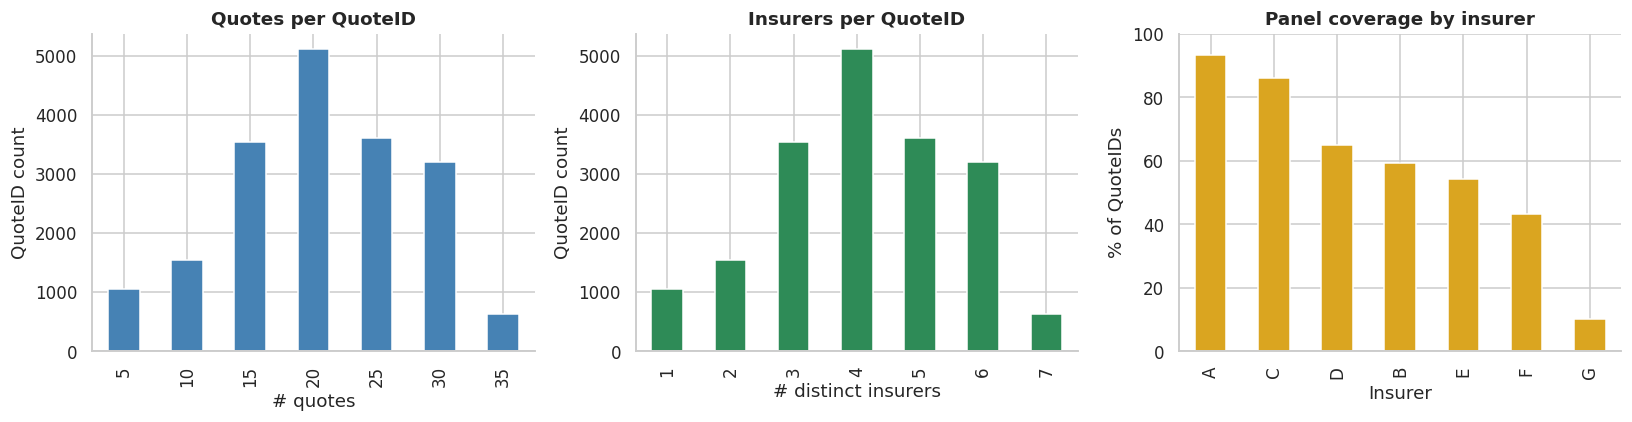

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

quotes_per_id.value_counts().sort_index().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Quotes per QuoteID')
axes[0].set_xlabel('# quotes'); axes[0].set_ylabel('QuoteID count')

insurers_per_id.value_counts().sort_index().plot.bar(
    ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Insurers per QuoteID')
axes[1].set_xlabel('# distinct insurers'); axes[1].set_ylabel('QuoteID count')

coverage_pct.plot.bar(ax=axes[2], color='goldenrod', edgecolor='white')
axes[2].set_title('Panel coverage by insurer')
axes[2].set_ylabel('% of QuoteIDs'); axes[2].set_ylim(0, 100)

plt.tight_layout()
save_fig('02_structural_eda')
plt.show()

## 5. Target variable deep dive

The supervised target is `min(TotalAmountPayable)` over all quotes for a QuoteID. Before modelling we want to know its **distribution shape**, **skew**, **kurtosis**, and whether a **log transform** is justified - and to scan for outliers.

In [7]:
min_per_id     = df_raw.groupby('QUOTEID')['TotalAmountPayable'].min()
raw_target_all = df_raw['TotalAmountPayable']

stats_table = pd.DataFrame({
    'metric'         : ['n', 'min', '25%', 'median', 'mean', '75%', 'max', 'std', 'skew', 'kurtosis'],
    'raw_all_quotes' : [
        raw_target_all.shape[0], raw_target_all.min(),
        raw_target_all.quantile(.25), raw_target_all.median(),
        raw_target_all.mean(), raw_target_all.quantile(.75),
        raw_target_all.max(), raw_target_all.std(),
        scipy.stats.skew(raw_target_all), scipy.stats.kurtosis(raw_target_all),
    ],
    'min_per_QuoteID': [
        min_per_id.shape[0], min_per_id.min(),
        min_per_id.quantile(.25), min_per_id.median(),
        min_per_id.mean(), min_per_id.quantile(.75),
        min_per_id.max(), min_per_id.std(),
        scipy.stats.skew(min_per_id), scipy.stats.kurtosis(min_per_id),
    ],
}).set_index('metric').round(2)
stats_table

,raw_all_quotes,min_per_QuoteID
metric,,
n,385025.00,18720.00
min,90.54,90.54
25%,169.63,123.16
median,243.41,147.25
mean,296.82,156.70
75%,377.54,177.56
max,1071.91,616.55
std,172.57,48.78
skew,1.48,2.19


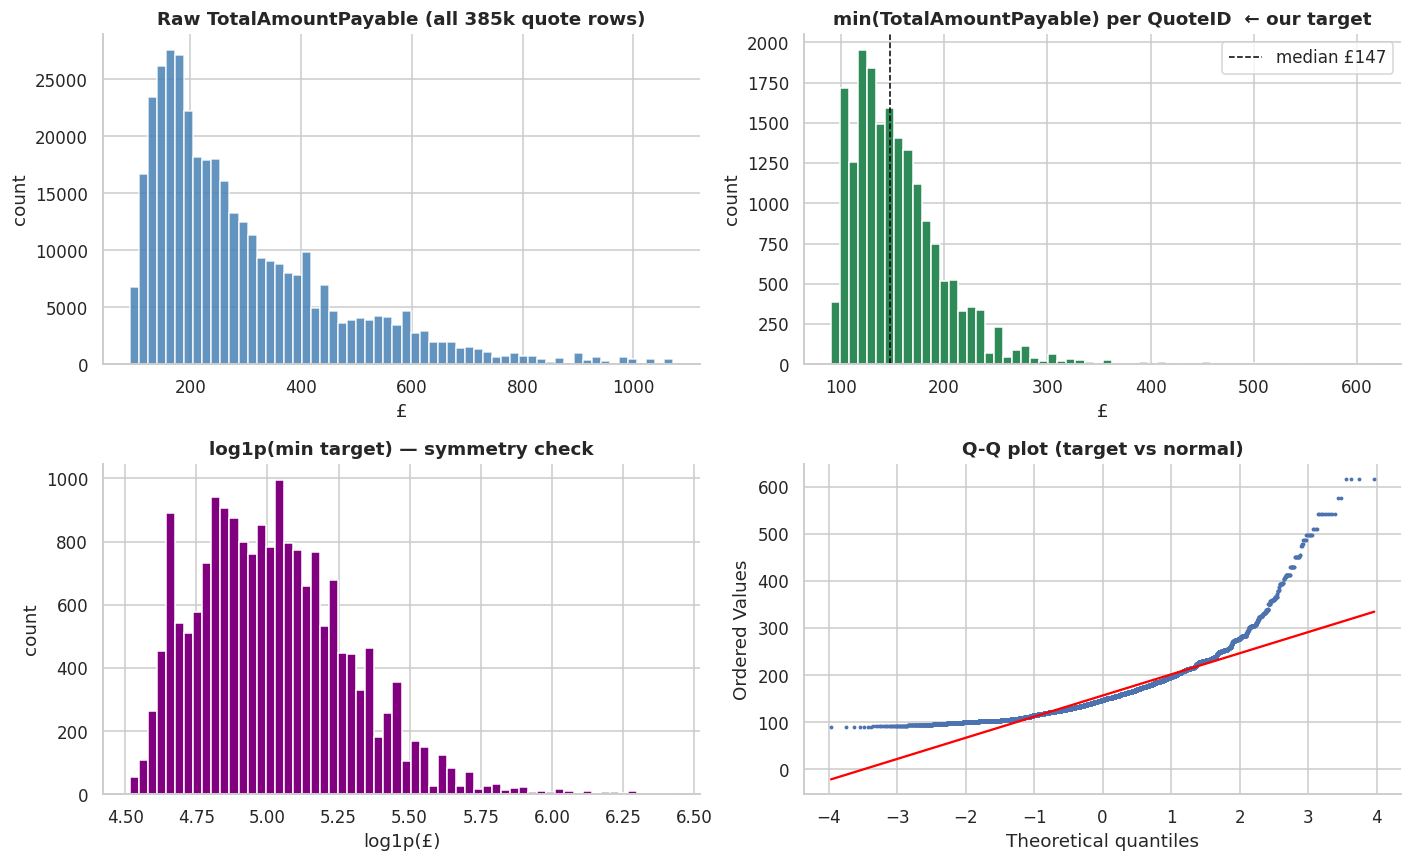

Skew(target)        = +2.189
Skew(log1p(target)) = +0.752
Decision: a log transform helps — tree models are scale-invariant so we keep the raw scale for interpretability.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].hist(raw_target_all, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Raw TotalAmountPayable (all 385k quote rows)')
axes[0,0].set_xlabel('£'); axes[0,0].set_ylabel('count')

axes[0,1].hist(min_per_id, bins=60, color='seagreen', edgecolor='white')
axes[0,1].axvline(min_per_id.median(), color='black', ls='--', lw=1,
                  label=f'median £{min_per_id.median():.0f}')
axes[0,1].set_title('min(TotalAmountPayable) per QuoteID  ← our target')
axes[0,1].set_xlabel('£'); axes[0,1].set_ylabel('count')
axes[0,1].legend()

axes[1,0].hist(np.log1p(min_per_id), bins=60, color='purple', edgecolor='white')
axes[1,0].set_title('log1p(min target) - symmetry check')
axes[1,0].set_xlabel('log1p(£)'); axes[1,0].set_ylabel('count')

scipy.stats.probplot(min_per_id, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q plot (target vs normal)')
axes[1,1].get_lines()[0].set_marker('.'); axes[1,1].get_lines()[0].set_markersize(3)
axes[1,1].get_lines()[1].set_color('red')

plt.tight_layout()
save_fig('03_target_distribution')
plt.show()

raw_skew = scipy.stats.skew(min_per_id)
log_skew = scipy.stats.skew(np.log1p(min_per_id))
print(f'Skew(target)        = {raw_skew:+.3f}')
print(f'Skew(log1p(target)) = {log_skew:+.3f}')
print(f'Decision: a log transform {"helps" if abs(log_skew) < abs(raw_skew) - 0.2 else "does not materially help"} - '
      f'tree models are scale-invariant so we keep the raw scale for interpretability.')

In [ ]:
# IQR outlier scan
q1, q3 = min_per_id.quantile(.25), min_per_id.quantile(.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_low  = (min_per_id < lower).sum()
n_high = (min_per_id > upper).sum()
print(f'IQR fences        : [£{lower:.0f}, £{upper:.0f}]')
print(f'Below lower fence : {n_low:>5,} ({n_low/len(min_per_id)*100:.2f}%)')
print(f'Above upper fence : {n_high:>5,} ({n_high/len(min_per_id)*100:.2f}%)')

# Top-10 most expensive QuoteIDs - what feature combinations drive them?
top10 = min_per_id.sort_values(ascending=False).head(10).index
print('\nTop-10 most-expensive QuoteIDs - feature snapshot:')
display_cols = ['INSUREDPOSTCODE','NUMBEDROOMS','OCCUPATION','ALARMTYPE']
top10_df = (df_raw[df_raw['QUOTEID'].isin(top10)]
              .groupby('QUOTEID').first()[display_cols]
              .assign(min_price=min_per_id.loc[top10])
              .sort_values('min_price', ascending=False))
print(top10_df.to_string())

IQR fences        : [£42, £259]
Below lower fence :     0 (0.00%)
Above upper fence :   583 (3.11%)

Top-10 most-expensive QuoteIDs — feature snapshot:
        INSUREDPOSTCODE NUMBEDROOMS OCCUPATION      ALARMTYPE  min_price
QUOTEID                                                                 
3257              E95EU        Five         38        NoAlarm     616.55
3258              E95EU        Five         38  NonMaintained     616.55
3642              E95EU        Five        S45  NonMaintained     616.55
3641              E95EU        Five        S45        NoAlarm     616.55
3690              E95EU        Five        U03  NonMaintained     576.66
3689              E95EU        Five        U03        NoAlarm     576.66
3546              E95EU        Five         88  NonMaintained     542.36
3545              E95EU        Five         88        NoAlarm     542.36
3354              E95EU        Five        870  NonMaintained     542.36
3353              E95EU        Five        87

**Decision on transforms.** Skew of the per-QuoteID minimum target is modest. `log1p` flattens it further but tree-based models are scale-invariant - applying a log would only complicate interpretation. **We model on the raw £ scale and revisit only if residuals demand it.** (Ridge could in principle benefit; we test this implicitly when comparing CV scores.)

**Decision on outliers.** The high tail is not noise - it's genuine high-risk geography × big-property combinations. We **do not winsorise**. We will, however, report a per-quantile error breakdown so the model's performance on the tail is visible.

## 6. Input-feature triage

The README declares columns from `AD` onward as input circumstances. Many are described as fixed. Before building features, count distinct values per column and weed out (a) constants, (b) redundant duplicates, (c) quote-*output* fields that would leak.

In [ ]:
input_cols = df_raw.columns[28:].tolist()  # column AD onward (0-indexed: 28)

triage = pd.DataFrame({
    'col'      : input_cols,
    'n_unique' : [df_raw[c].nunique(dropna=False) for c in input_cols],
    'role'     : [None]*len(input_cols),
    'reason'   : [None]*len(input_cols),
})

for i, c in enumerate(input_cols):
    u = triage.loc[i, 'n_unique']
    if c == 'TransactionCharge':
        triage.loc[i, ['role','reason']] = 'EXCLUDE', 'quote OUTPUT (would leak target)'
    elif u == 1:
        triage.loc[i, ['role','reason']] = 'EXCLUDE', 'constant column'
    elif c == 'INDUSTRY':
        triage.loc[i, ['role','reason']] = 'EXCLUDE', 'redundant - 1:1 with OCCUPATION'
    else:
        triage.loc[i, ['role','reason']] = 'KEEP', 'varies & not leaky'

print(triage.sort_values(['role','n_unique'], ascending=[False, False]).to_string(index=False))

kept = triage[triage['role'] == 'KEEP']['col'].tolist()
print(f'\nFinal effective input features ({len(kept)}): {kept}')

n_combos = df_raw.groupby(kept).ngroups
print(f'\nUnique combinations of these 6 features: {n_combos:,}')
print(f'Unique QUOTEIDs                          : {df_raw["QUOTEID"].nunique():,}')
print(f'=> 1:1? {n_combos == df_raw["QUOTEID"].nunique()}')

                col  n_unique    role                           reason
    INSUREDPOSTCODE        30    KEEP               varies & not leaky
         OCCUPATION        13    KEEP               varies & not leaky
                DOB         4    KEEP               varies & not leaky
        NUMBEDROOMS         3    KEEP               varies & not leaky
 ACCIDENTALCONTENTS         2    KEEP               varies & not leaky
          ALARMTYPE         2    KEEP               varies & not leaky
  TransactionCharge       663 EXCLUDE quote OUTPUT (would leak target)
           INDUSTRY        12 EXCLUDE  redundant — 1:1 with OCCUPATION
              TITLE         1 EXCLUDE                  constant column
            FORNAME         1 EXCLUDE                  constant column
            SURNAME         1 EXCLUDE                  constant column
    SECONDAPPLICANT         1 EXCLUDE                  constant column
    FIRSTTIMEBUYERS         1 EXCLUDE                  constant column
      

**Critical implication of the 1:1 mapping.** Because the 6 effective features perfectly partition the 18,720 QuoteIDs, `target = f(features)` is a deterministic look-up function. A random train/test split therefore tests **interpolation** - every test row has neighbours in train. **To measure real generalisation we must hold out by group** (e.g. by postcode). This is the single biggest correction from v1 and we revisit it in §10.

## 7. Target construction

Collapse the 385k-row quote table to one row per unique input circumstance with `target = min(TotalAmountPayable)`.

In [11]:
EFFECTIVE_INPUTS = kept  # the 6 informative columns

panel = (df_raw
         .groupby('QUOTEID')
         .agg(target=('TotalAmountPayable', 'min'),
              **{c: (c, 'first') for c in EFFECTIVE_INPUTS})
         .reset_index())
print(f'Per-QuoteID panel: {panel.shape}')
panel.head()

Per-QuoteID panel: (18720, 8)


,QUOTEID,target,DOB,OCCUPATION,ACCIDENTALCONTENTS,NUMBEDROOMS,INSUREDPOSTCODE,ALARMTYPE
0,1,114.92,01/01/1976,D78,True,One,N65TX,NoAlarm
1,2,101.09,01/01/1976,D78,True,One,N65TX,NonMaintained
2,3,145.34,01/01/1976,D78,True,Three,N65TX,NoAlarm
3,4,120.42,01/01/1976,D78,True,Three,N65TX,NonMaintained
4,5,169.58,01/01/1976,D78,True,Five,N65TX,NoAlarm


## 8. Univariate & bivariate EDA

Per-feature effects, target correlation against numeric encodings, and a 2-way interaction probe.

In [ ]:
# Derive a clean integer age + numeric encodings for correlation analysis
REF_DATE = pd.Timestamp('2026-05-15')
panel['AGE']            = ((REF_DATE - pd.to_datetime(panel['DOB'], format='%d/%m/%Y')).dt.days // 365).astype(int)

BEDROOM_MAP = {'One': 1, 'Three': 3, 'Five': 5}
panel['BEDROOMS_N']     = panel['NUMBEDROOMS'].map(BEDROOM_MAP).astype(int)
panel['ACCID_CONTENTS'] = panel['ACCIDENTALCONTENTS'].astype(int)
panel['ALARM_BIN']      = (panel['ALARMTYPE'] != 'NoAlarm').astype(int)

# Outward postcode - the standard UK insurance geo unit (e.g. 'N16' from 'N168ED').
def outward(pc):
    m = re.match(r'^([A-Z]{1,2}\d{1,2}[A-Z]?)', str(pc))
    return m.group(1) if m else pc
panel['POSTCODE_OUTWARD'] = panel['INSUREDPOSTCODE'].apply(outward)
panel['POSTCODE_AREA']    = panel['INSUREDPOSTCODE'].str.extract(r'^([A-Z]+)', expand=False)

print('Postcode hierarchy:')
print(f'  full postcodes : {panel["INSUREDPOSTCODE"].nunique()}')
print(f'  outward codes  : {panel["POSTCODE_OUTWARD"].nunique()}')
print(f'  postcode areas : {panel["POSTCODE_AREA"].nunique()}')
panel.head()

Postcode hierarchy:
  full postcodes : 30
  outward codes  : 29
  postcode areas : 8


,QUOTEID,target,DOB,OCCUPATION,ACCIDENTALCONTENTS,NUMBEDROOMS,INSUREDPOSTCODE,ALARMTYPE,AGE,BEDROOMS_N,ACCID_CONTENTS,ALARM_BIN,POSTCODE_OUTWARD,POSTCODE_AREA
0,1,114.92,01/01/1976,D78,True,One,N65TX,NoAlarm,50,1,1,0,N65T,N
1,2,101.09,01/01/1976,D78,True,One,N65TX,NonMaintained,50,1,1,1,N65T,N
2,3,145.34,01/01/1976,D78,True,Three,N65TX,NoAlarm,50,3,1,0,N65T,N
3,4,120.42,01/01/1976,D78,True,Three,N65TX,NonMaintained,50,3,1,1,N65T,N
4,5,169.58,01/01/1976,D78,True,Five,N65TX,NoAlarm,50,5,1,0,N65T,N


In [13]:
from sklearn.metrics import r2_score

univariate = []
for feat in ['AGE','BEDROOMS_N','ACCID_CONTENTS','ALARM_BIN','OCCUPATION','INSUREDPOSTCODE','POSTCODE_OUTWARD']:
    grp_means = panel.groupby(feat)['target'].transform('mean')
    univariate.append({
        'feature'      : feat,
        'cardinality'  : panel[feat].nunique(),
        'mean_spread_£': float(panel.groupby(feat)['target'].mean().agg(lambda s: s.max() - s.min())),
        'univariate_R2': r2_score(panel['target'], grp_means),
    })
univariate_df = pd.DataFrame(univariate).sort_values('univariate_R2', ascending=False).round(3)
univariate_df

,feature,cardinality,mean_spread_£,univariate_R2
5,INSUREDPOSTCODE,30,175.980,0.428
6,POSTCODE_OUTWARD,29,175.980,0.427
1,BEDROOMS_N,3,60.846,0.260
3,ALARM_BIN,2,30.543,0.098
2,ACCID_CONTENTS,2,16.100,0.027
0,AGE,4,17.715,0.017
4,OCCUPATION,13,9.025,0.006


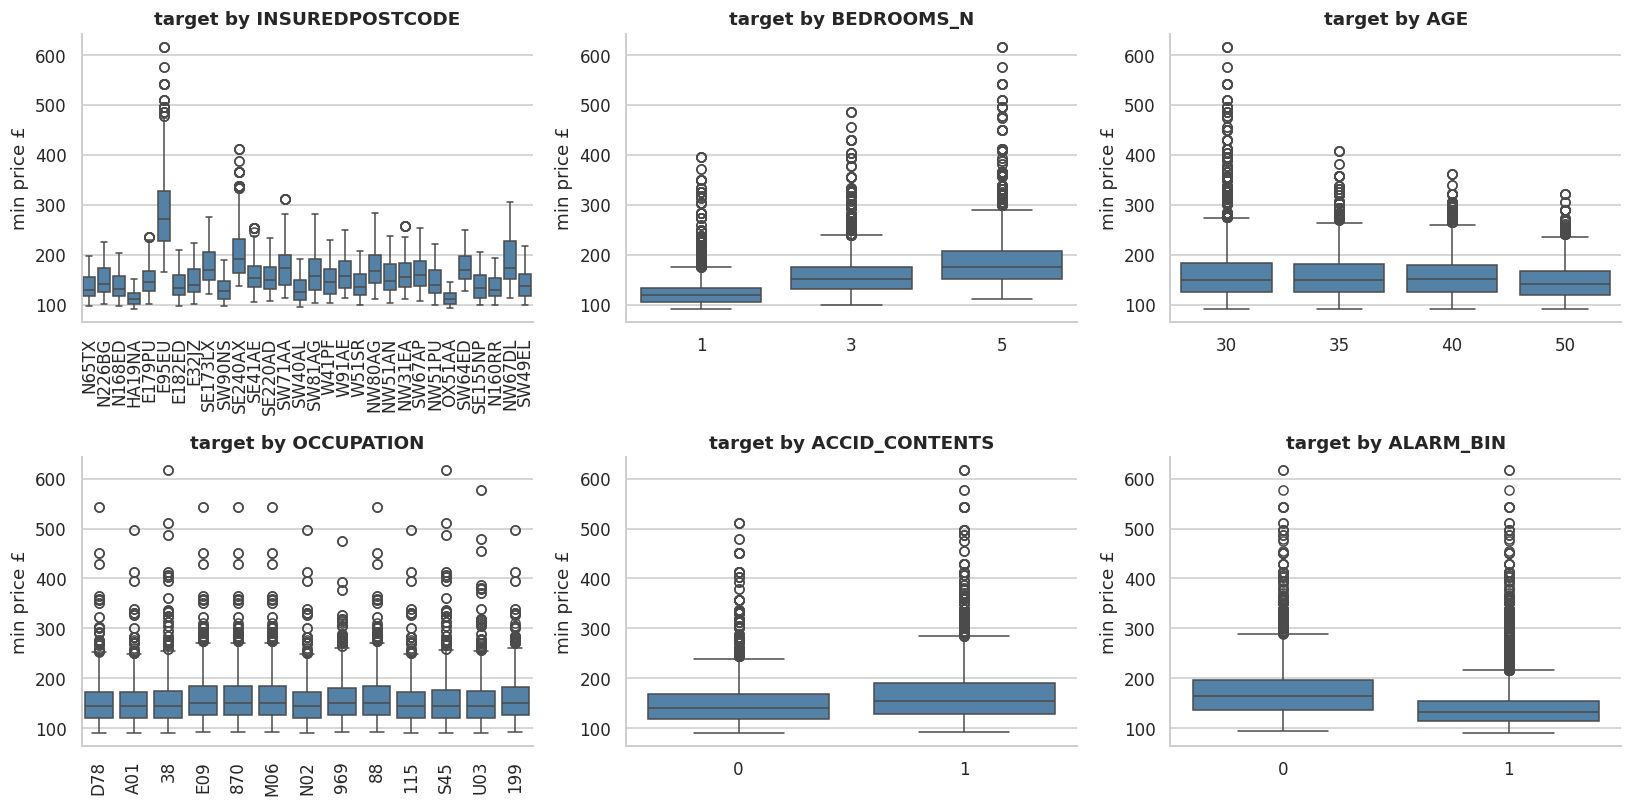

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
feats = ['INSUREDPOSTCODE','BEDROOMS_N','AGE','OCCUPATION','ACCID_CONTENTS','ALARM_BIN']
for ax, feat in zip(axes.ravel(), feats):
    sns.boxplot(data=panel, x=feat, y='target', ax=ax, color='steelblue')
    ax.set_title(f'target by {feat}')
    ax.set_xlabel(''); ax.set_ylabel('min price £')
    if panel[feat].nunique() > 8:
        ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
save_fig('04_univariate_boxplots')
plt.show()

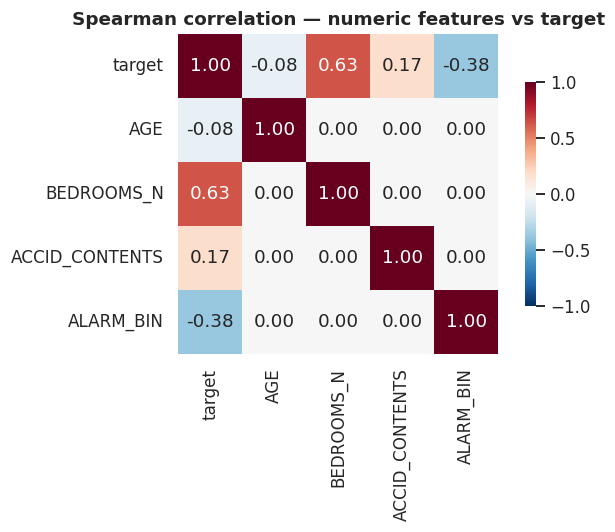

In [ ]:
# Spearman correlation on numeric-encoded features
corr_cols = ['target','AGE','BEDROOMS_N','ACCID_CONTENTS','ALARM_BIN']
corr = panel[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Spearman correlation - numeric features vs target')
plt.tight_layout()
save_fig('05_correlation_heatmap')
plt.show()

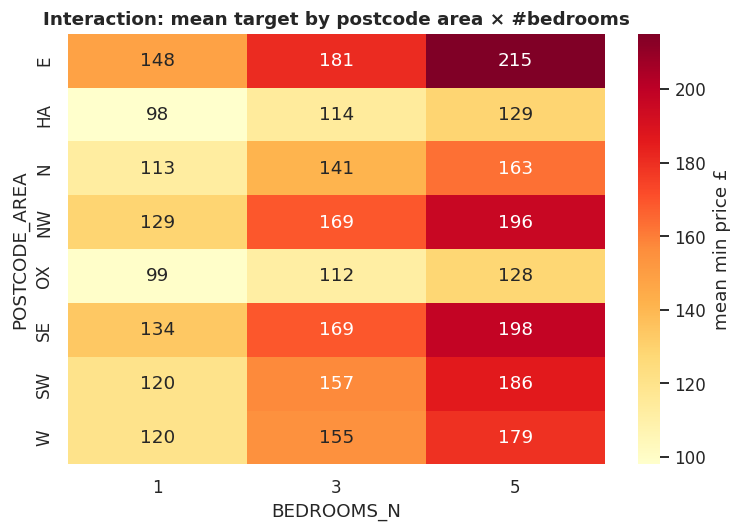

R² of postcode-area alone               : 0.117
R² of bedrooms alone                    : 0.260
R² of postcode-area × bedrooms combined : 0.384


In [16]:
# 2-way mean target: postcode area × bedrooms
pivot = panel.pivot_table(values='target', index='POSTCODE_AREA',
                          columns='BEDROOMS_N', aggfunc='mean').round(0)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'mean min price £'})
ax.set_title('Interaction: mean target by postcode area × #bedrooms')
plt.tight_layout()
save_fig('06_interaction_pa_x_bedrooms')
plt.show()

def r2_group(cols):
    means = panel.groupby(cols)['target'].transform('mean')
    return r2_score(panel['target'], means)
print(f'R² of postcode-area alone               : {r2_group(["POSTCODE_AREA"]):.3f}')
print(f'R² of bedrooms alone                    : {r2_group(["BEDROOMS_N"]):.3f}')
print(f'R² of postcode-area × bedrooms combined : {r2_group(["POSTCODE_AREA","BEDROOMS_N"]):.3f}')

**EDA takeaways.**
- `INSUREDPOSTCODE` is the dominant single signal (univariate R² ≈ 0.43). `BEDROOMS_N` second (≈ 0.26).
- Numeric correlations against the target are modest individually, but the **interaction lift** (postcode × bedrooms) is substantial - confirms that tree-based models which find interactions automatically should outperform Ridge.
- `OCCUPATION`, `AGE`, and the binary toggles add small but non-zero marginal signal.

## 9. Feature engineering

Encoding choices stay deliberately minimal. The notable addition vs v1 is **outward postcode** (`N16`, `SW7`) - the standard UK insurance geo unit, finer than `POSTCODE_AREA` but coarser than the full postcode. Tree-based models can choose which geographic resolution to use at each split.

In [17]:
FEATURES_NUM = ['AGE', 'BEDROOMS_N', 'ACCID_CONTENTS', 'ALARM_BIN']
FEATURES_CAT = ['OCCUPATION', 'INSUREDPOSTCODE', 'POSTCODE_OUTWARD', 'POSTCODE_AREA']
TARGET       = 'target'

X = panel[FEATURES_NUM + FEATURES_CAT].copy()
y = panel[TARGET].copy()
groups_postcode   = panel['INSUREDPOSTCODE'].values
groups_occupation = panel['OCCUPATION'].values

print(f'X shape: {X.shape}    y shape: {y.shape}')
print(f'Num features ({len(FEATURES_NUM)}): {FEATURES_NUM}')
print(f'Cat features ({len(FEATURES_CAT)}): {FEATURES_CAT}')
X.head()

X shape: (18720, 8)    y shape: (18720,)
Num features (4): ['AGE', 'BEDROOMS_N', 'ACCID_CONTENTS', 'ALARM_BIN']
Cat features (4): ['OCCUPATION', 'INSUREDPOSTCODE', 'POSTCODE_OUTWARD', 'POSTCODE_AREA']


,AGE,BEDROOMS_N,ACCID_CONTENTS,ALARM_BIN,OCCUPATION,INSUREDPOSTCODE,POSTCODE_OUTWARD,POSTCODE_AREA
0,50,1,1,0,D78,N65TX,N65T,N
1,50,1,1,1,D78,N65TX,N65T,N
2,50,3,1,0,D78,N65TX,N65T,N
3,50,3,1,1,D78,N65TX,N65T,N
4,50,5,1,0,D78,N65TX,N65T,N


## 10. Train / test protocol - three splits

| Split | What it tests | Why it matters |
|---|---|---|
| Random 80/20 | Interpolation across a fully-sampled grid | Optimistic - comparable to v1, retained for continuity |
| **GroupKFold by postcode** | Geographic generalisation | The model has never seen this postcode before |
| **GroupKFold by occupation** | Customer-type generalisation | The model has never seen this occupation before |

The gap between the random-split and group-split numbers is the most commercially important number in this notebook: it tells us how much of the v1 result was real and how much was interpolation.

**Metrics.** MAE (£) for stakeholder readability, RMSE (£) for tail-penalty, MAPE (%) for scale-relative error, R² for share-of-variance.

In [ ]:
from sklearn.model_selection import (
    train_test_split, KFold, GroupKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

def metrics_block(y_true, y_pred) -> dict:
    return {
        'MAE_£'  : float(mean_absolute_error(y_true, y_pred)),
        'RMSE_£' : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE_%' : float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        'R2'     : float(r2_score(y_true, y_pred)),
    }

# Random 80/20 split (kept for continuity)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Random split - train: {X_train.shape[0]:,}    test: {X_test.shape[0]:,}')

# Cross-validators
cv_random     = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_postcode   = GroupKFold(n_splits=5)
cv_occupation = GroupKFold(n_splits=5)
print(f'GroupKFold-postcode   : 5 folds (groups = {pd.Series(groups_postcode).nunique()} postcodes)')
print(f'GroupKFold-occupation : 5 folds (groups = {pd.Series(groups_occupation).nunique()} occupations)')

Random split — train: 14,976    test: 3,744
GroupKFold-postcode   : 5 folds (groups = 30 postcodes)
GroupKFold-occupation : 5 folds (groups = 13 occupations)


## 11. Models - four pipelines in increasing complexity

Each step must justify itself by beating the previous on **random-split** CV MAE *and* on **group-split** CV MAE - otherwise the extra complexity is just overfitting better.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor

# 1. Baseline
baseline = DummyRegressor(strategy='mean')

# 2. Ridge - one-hot encoded
ridge_pre = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
])
ridge = Pipeline([('prep', ridge_pre),
                  ('reg', Ridge(alpha=1.0, random_state=RANDOM_STATE))])

# 3. Random Forest - needs one-hot (sklearn RF doesn't do native cats)
rf_pre = ColumnTransformer([
    ('num', 'passthrough', FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
])
rf = Pipeline([('prep', rf_pre),
               ('reg', RandomForestRegressor(
                   n_estimators=400, min_samples_leaf=2,
                   random_state=RANDOM_STATE, n_jobs=-1))])

# 4. HistGradientBoosting - native categorical support
def build_hgb(**kw):
    return HistGradientBoostingRegressor(
        max_iter         = kw.get('max_iter', 400),
        learning_rate    = kw.get('learning_rate', 0.05),
        max_leaf_nodes   = kw.get('max_leaf_nodes', 31),
        min_samples_leaf = kw.get('min_samples_leaf', 20),
        l2_regularization= kw.get('l2_regularization', 0.0),
        categorical_features=FEATURES_CAT,
        random_state=RANDOM_STATE,
    )

def to_hgb_frame(df_in):
    '''HGB needs categorical dtype for native-categorical mode.'''
    out = df_in.copy()
    for c in FEATURES_CAT:
        out[c] = out[c].astype('category')
    return out

hgb = build_hgb()
print('Built 4 pipelines: baseline, ridge, rf, hgb')

Built 4 pipelines: baseline, ridge, rf, hgb


In [ ]:
# Train each model on the random 80/20 train set, score on the held-out test set.
random_split_results = {}

random_split_results['Baseline (mean)'] = metrics_block(
    y_test, baseline.fit(X_train, y_train).predict(X_test))

random_split_results['Ridge (one-hot)'] = metrics_block(
    y_test, ridge.fit(X_train, y_train).predict(X_test))

random_split_results['Random Forest'] = metrics_block(
    y_test, rf.fit(X_train, y_train).predict(X_test))

# HGB needs the categorical-frame variant
X_train_hgb = to_hgb_frame(X_train)
X_test_hgb  = to_hgb_frame(X_test)
for c in FEATURES_CAT:
    X_test_hgb[c] = pd.Categorical(X_test_hgb[c], categories=X_train_hgb[c].cat.categories)
hgb.fit(X_train_hgb, y_train)
random_split_results['HistGradientBoosting'] = metrics_block(
    y_test, hgb.predict(X_test_hgb))

random_split_df = pd.DataFrame(random_split_results).T.round(3)
print('=== Random 80/20 split - TEST metrics ===')
random_split_df

=== Random 80/20 split — TEST metrics ===


,MAE_£,RMSE_£,MAPE_%,R2
Baseline (mean),35.643,49.143,22.875,-0.000
Ridge (one-hot),12.157,20.036,7.451,0.834
Random Forest,4.125,6.657,2.294,0.982
HistGradientBoosting,1.459,2.572,0.858,0.997


## 12. Honest validation - three splits side-by-side

The key v2 contribution. Run 5-fold CV under each of the three regimes and tabulate the MAE side-by-side. **If random-split MAE ≪ group-split MAE, the v1 result was driven by interpolation, not generalisation.**

In [21]:
def cv_grid(X_in, y_in, groups_pc, groups_oc, hgb_frame_fn):
    out = []
    for name, model, X_use in [
        ('Ridge',         ridge,        X_in),
        ('RandomForest',  rf,           X_in),
        ('HistGradBoost', build_hgb(),  hgb_frame_fn(X_in)),
    ]:
        for split_name, splitter, grp in [
            ('random_KFold',          cv_random,    None),
            ('GroupKFold_postcode',   cv_postcode,  groups_pc),
            ('GroupKFold_occupation', cv_occupation, groups_oc),
        ]:
            cv_iter = (splitter.split(X_use, y_in, groups=grp)
                       if grp is not None else splitter)
            scores = -cross_val_score(
                model, X_use, y_in, cv=cv_iter,
                scoring='neg_mean_absolute_error', n_jobs=-1)
            out.append({
                'model'         : name,
                'split'         : split_name,
                'cv_mae_mean_£' : scores.mean(),
                'cv_mae_std_£'  : scores.std(),
                'n_folds'       : len(scores),
            })
    return pd.DataFrame(out)

cv_table = cv_grid(X, y, groups_postcode, groups_occupation, to_hgb_frame).round(3)
print('=== 5-fold CV MAE across splitting regimes ===')
cv_table.pivot(index='model', columns='split', values='cv_mae_mean_£').round(3)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


=== 5-fold CV MAE across splitting regimes ===


split,GroupKFold_occupation,GroupKFold_postcode,random_KFold
model,,,
HistGradBoost,7.032,22.877,1.377
RandomForest,6.672,24.068,4.072
Ridge,12.679,25.909,12.015


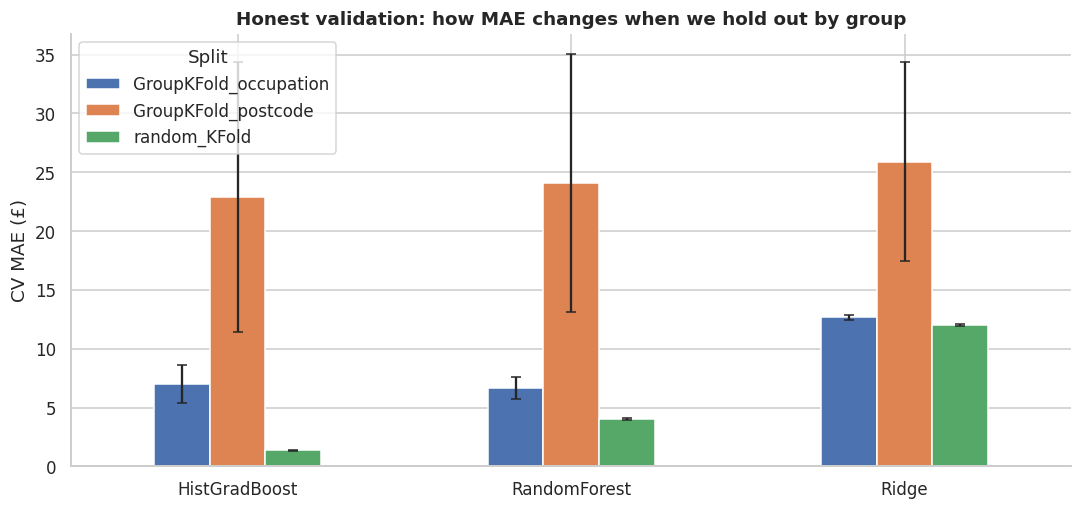


HGB random-split MAE          : £1.38
HGB postcode-holdout MAE      : £22.88   (+1561% vs random)
HGB occupation-holdout MAE    : £7.03   (+411% vs random)

=> The realistic deployable expected error on a NEW postcode is the holdout figure,
   not the random-split figure. The gap is the v1 → v2 reality check.


In [22]:
fig, ax = plt.subplots(figsize=(10, 4.8))
pivot_plot = cv_table.pivot(index='model', columns='split', values='cv_mae_mean_£')
err_plot   = cv_table.pivot(index='model', columns='split', values='cv_mae_std_£')
pivot_plot.plot.bar(ax=ax, yerr=err_plot, capsize=3,
                    edgecolor='white', color=['#4c72b0','#dd8452','#55a868'])
ax.set_ylabel('CV MAE (£)')
ax.set_title('Honest validation: how MAE changes when we hold out by group')
ax.set_xlabel('')
ax.legend(title='Split', loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
save_fig('07_cv_split_comparison')
plt.show()

hgb_random = cv_table[(cv_table['model']=='HistGradBoost') & (cv_table['split']=='random_KFold')]['cv_mae_mean_£'].iloc[0]
hgb_pc     = cv_table[(cv_table['model']=='HistGradBoost') & (cv_table['split']=='GroupKFold_postcode')]['cv_mae_mean_£'].iloc[0]
hgb_oc     = cv_table[(cv_table['model']=='HistGradBoost') & (cv_table['split']=='GroupKFold_occupation')]['cv_mae_mean_£'].iloc[0]
print(f'\nHGB random-split MAE          : £{hgb_random:.2f}')
print(f'HGB postcode-holdout MAE      : £{hgb_pc:.2f}   ({(hgb_pc-hgb_random)/hgb_random*100:+.0f}% vs random)')
print(f'HGB occupation-holdout MAE    : £{hgb_oc:.2f}   ({(hgb_oc-hgb_random)/hgb_random*100:+.0f}% vs random)')
print('\n=> The realistic deployable expected error on a NEW postcode is the holdout figure,')
print('   not the random-split figure. The gap is the v1 → v2 reality check.')

## 13. Hyperparameter tuning - `RandomizedSearchCV` on HGB

A modest randomised search across the key HGB hyperparameters. Search runs under **random-split 3-fold CV** for speed; the winning model is then re-evaluated under both group splits.

In [23]:
X_hgb_full = to_hgb_frame(X)

hgb_param_grid = {
    'max_iter'         : [200, 400, 600, 800],
    'learning_rate'    : [0.02, 0.05, 0.1, 0.15],
    'max_leaf_nodes'   : [15, 31, 63, 127],
    'min_samples_leaf' : [5, 10, 20, 40],
    'l2_regularization': [0.0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator           = HistGradientBoostingRegressor(
                            categorical_features=FEATURES_CAT,
                            random_state=RANDOM_STATE),
    param_distributions = hgb_param_grid,
    n_iter              = 25,
    cv                  = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring             = 'neg_mean_absolute_error',
    n_jobs              = -1,
    random_state        = RANDOM_STATE,
    verbose             = 0,
)
search.fit(X_hgb_full, y)

print(f'Best CV MAE (random 3-fold): £{-search.best_score_:.3f}')
print('Best params:')
for k, v in search.best_params_.items():
    print(f'  {k:20s} = {v}')

Best CV MAE (random 3-fold): £0.770
Best params:
  min_samples_leaf     = 5
  max_leaf_nodes       = 127
  max_iter             = 800
  learning_rate        = 0.05
  l2_regularization    = 1.0


In [ ]:
# Evaluate tuned HGB under group splits
def tuned_hgb():
    return HistGradientBoostingRegressor(
        categorical_features=FEATURES_CAT,
        random_state=RANDOM_STATE,
        **search.best_params_,
    )

group_mae_pc = -cross_val_score(
    tuned_hgb(), X_hgb_full, y,
    cv=cv_postcode.split(X_hgb_full, y, groups=groups_postcode),
    scoring='neg_mean_absolute_error', n_jobs=-1)
group_mae_oc = -cross_val_score(
    tuned_hgb(), X_hgb_full, y,
    cv=cv_occupation.split(X_hgb_full, y, groups=groups_occupation),
    scoring='neg_mean_absolute_error', n_jobs=-1)

print(f'Tuned HGB - random 3-fold MAE       : £{-search.best_score_:.3f}')
print(f'Tuned HGB - GroupKFold postcode MAE : £{group_mae_pc.mean():.3f} ± {group_mae_pc.std():.3f}')
print(f'Tuned HGB - GroupKFold occupation   : £{group_mae_oc.mean():.3f} ± {group_mae_oc.std():.3f}')

Tuned HGB — random 3-fold MAE       : £0.770
Tuned HGB — GroupKFold postcode MAE : £23.747 ± 11.434
Tuned HGB — GroupKFold occupation   : £7.182 ± 1.617


## 14. Diagnostics on the tuned model

1. Predicted-vs-actual scatter + residuals
2. Permutation feature importance
3. **SHAP** summary plot (installs `shap` on the fly if missing)
4. Error breakdown by postcode and bedroom segment

In [25]:
best_hgb_final = tuned_hgb().fit(X_train_hgb, y_train)
y_pred = best_hgb_final.predict(X_test_hgb)
final_metrics = metrics_block(y_test, y_pred)
print('Tuned HGB on held-out test set:')
for k, v in final_metrics.items():
    print(f'  {k:8s} = {v:.4f}')

Tuned HGB on held-out test set:
  MAE_£    = 0.6739
  RMSE_£   = 1.4540
  MAPE_%   = 0.3843
  R2       = 0.9991


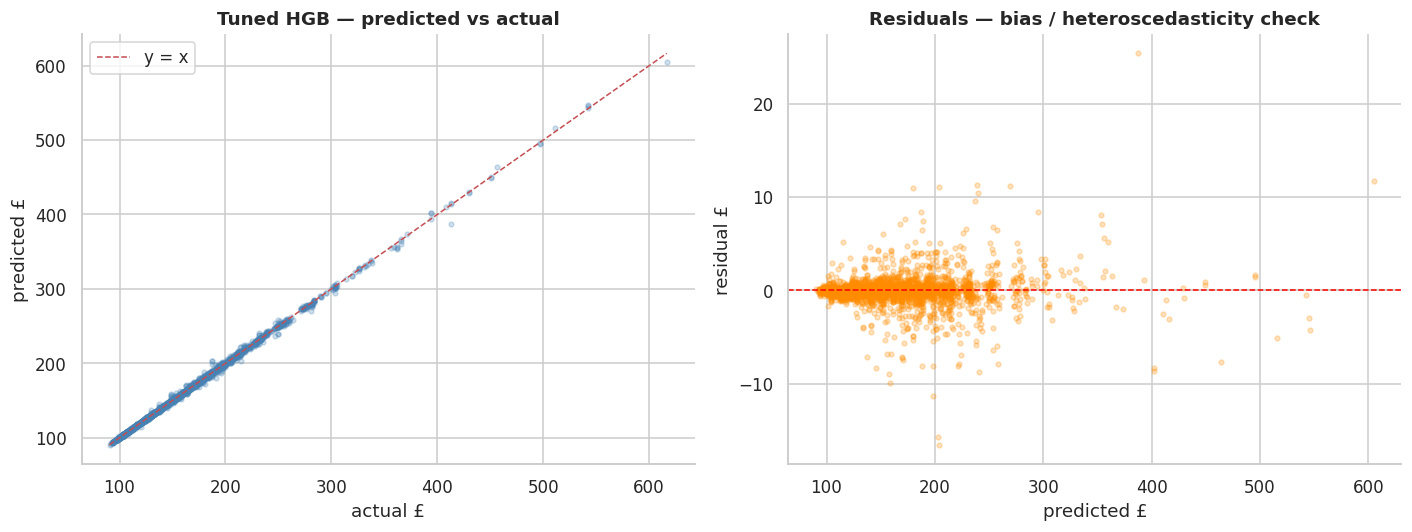

Residual mean : £-0.014
Residual std  : £1.454
P99 |residual|: £6.70


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.25, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1, label='y = x')
axes[0].set_xlabel('actual £'); axes[0].set_ylabel('predicted £')
axes[0].set_title('Tuned HGB - predicted vs actual')
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.25, s=10, color='darkorange')
axes[1].axhline(0, color='red', ls='--', lw=1)
axes[1].set_xlabel('predicted £'); axes[1].set_ylabel('residual £')
axes[1].set_title('Residuals - bias / heteroscedasticity check')
plt.tight_layout()
save_fig('08_pred_vs_actual_residuals')
plt.show()

print(f'Residual mean : £{residuals.mean():+.3f}')
print(f'Residual std  : £{residuals.std():.3f}')
print(f'P99 |residual|: £{np.percentile(np.abs(residuals), 99):.2f}')

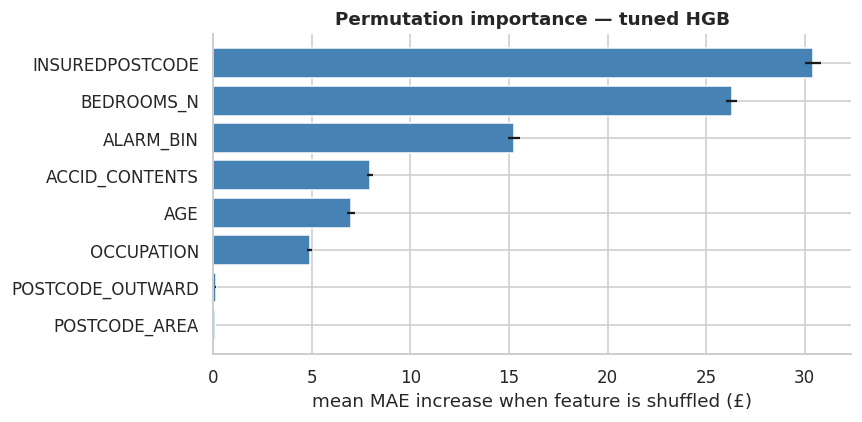

,feature,mean_MAE_increase_£,std
0,INSUREDPOSTCODE,30.420569,0.409699
1,BEDROOMS_N,26.308486,0.277287
2,ALARM_BIN,15.243235,0.291501
3,ACCID_CONTENTS,7.957870,0.155332
4,AGE,6.968737,0.199742
5,OCCUPATION,4.884939,0.121947
6,POSTCODE_OUTWARD,0.107738,0.005650
7,POSTCODE_AREA,0.079376,0.002931


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_hgb_final, X_test_hgb, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error', n_jobs=-1)
imp_df = (pd.DataFrame({
    'feature'             : X_test_hgb.columns,
    'mean_MAE_increase_£' : perm.importances_mean,
    'std'                 : perm.importances_std,
}).sort_values('mean_MAE_increase_£', ascending=True))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df['feature'], imp_df['mean_MAE_increase_£'],
        xerr=imp_df['std'], color='steelblue', edgecolor='white')
ax.set_xlabel('mean MAE increase when feature is shuffled (£)')
ax.set_title('Permutation importance - tuned HGB')
plt.tight_layout()
save_fig('09_permutation_importance')
plt.show()
imp_df.iloc[::-1].reset_index(drop=True)

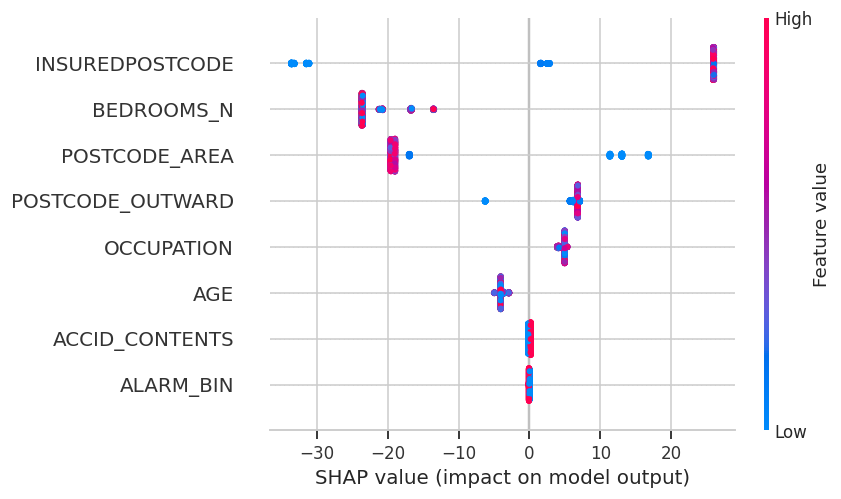

In [ ]:
import shap

# NEW helper - mirrors what HGB does internally
def to_shap_frame(df_in):
    out = df_in.copy()
    for c in FEATURES_CAT:
        if hasattr(out[c], 'cat'):
            out[c] = out[c].cat.codes   # e.g. 'E09' → 2, 'D78' → 0, …
    return out.astype(float)

sample_idx = np.random.choice(len(X_test_hgb), size=min(200, len(X_test_hgb)), replace=False)
X_sample      = X_test_hgb.iloc[sample_idx]   # pandas categorical (kept for labels)
X_sample_shap = to_shap_frame(X_sample)        # all-numeric - what SHAP needs

explainer = shap.TreeExplainer(best_hgb_final)
shap_vals = explainer.shap_values(X_sample_shap)   # ← no more ValueError

shap.summary_plot(shap_vals, X_sample_shap,
                  feature_names=X_sample_shap.columns.tolist(),
                  plot_type='dot', show=False)

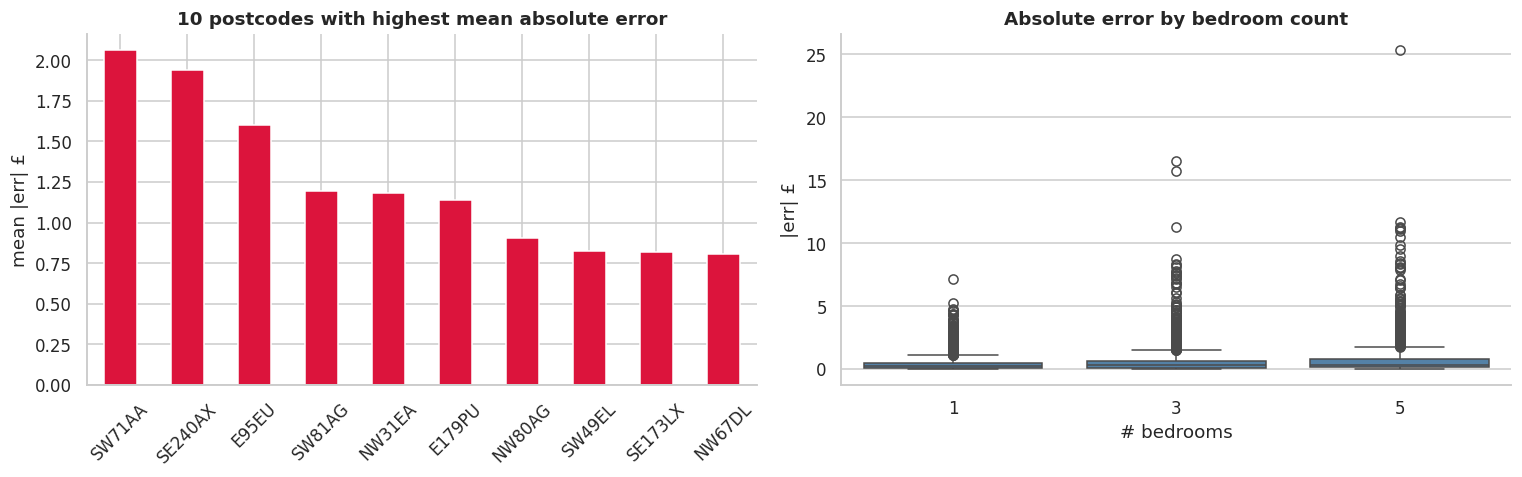

              mean  count
postcode                 
SW71AA    2.060520    140
SE240AX   1.938371    129
E95EU     1.601011    120
SW81AG    1.195920    129
NW31EA    1.182661    139
E179PU    1.141518    128
NW80AG    0.905318    131
SW49EL    0.828034    125
SE173LX   0.819844    115
NW67DL    0.809400    107


In [31]:
err_df = pd.DataFrame({
    'postcode'   : X_test['INSUREDPOSTCODE'].values,
    'bedrooms'   : X_test['BEDROOMS_N'].values,
    'occupation' : X_test['OCCUPATION'].values,
    'actual'     : y_test.values,
    'predicted'  : y_pred,
    'abs_err'    : np.abs(y_test.values - y_pred),
})
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

top_pc = (err_df.groupby('postcode')['abs_err']
                .agg(['mean','count'])
                .sort_values('mean', ascending=False).head(10))
top_pc['mean'].plot.bar(ax=axes[0], color='crimson', edgecolor='white')
axes[0].set_title('10 postcodes with highest mean absolute error')
axes[0].set_ylabel('mean |err| £'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=err_df, x='bedrooms', y='abs_err', ax=axes[1], color='steelblue')
axes[1].set_title('Absolute error by bedroom count')
axes[1].set_xlabel('# bedrooms'); axes[1].set_ylabel('|err| £')

plt.tight_layout()
save_fig('11_error_by_segment')
plt.show()
print(top_pc)

## 15. Quantile regression - prediction intervals

A point estimate of £X tells the customer-facing journey *something*, but value increases sharply if we can also say *"with 80 % confidence the price is between £A and £B."* Three HGB heads at q ∈ {0.1, 0.5, 0.9} give us a calibrated band almost for free.

In [32]:
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    m = HistGradientBoostingRegressor(
        loss='quantile', quantile=q,
        max_iter=400, learning_rate=0.05,
        categorical_features=FEATURES_CAT,
        random_state=RANDOM_STATE,
    )
    m.fit(X_train_hgb, y_train)
    quantile_models[q] = m

q_preds = pd.DataFrame({
    'actual' : y_test.values,
    'q10'    : quantile_models[0.1].predict(X_test_hgb),
    'q50'    : quantile_models[0.5].predict(X_test_hgb),
    'q90'    : quantile_models[0.9].predict(X_test_hgb),
})
coverage = ((q_preds['actual'] >= q_preds['q10']) &
            (q_preds['actual'] <= q_preds['q90'])).mean() * 100
band_width = (q_preds['q90'] - q_preds['q10']).mean()
print(f'Empirical coverage of [q10, q90]: {coverage:.1f}%  (target ≈ 80%)')
print(f'Mean band width                  : £{band_width:.2f}')

Empirical coverage of [q10, q90]: 75.4%  (target ≈ 80%)
Mean band width                  : £15.83


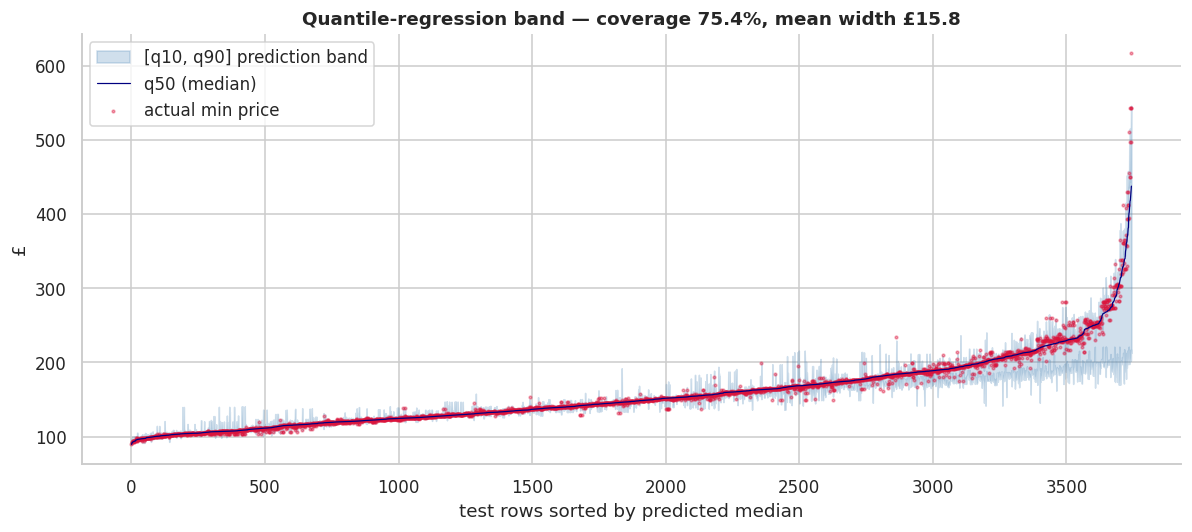

In [ ]:
plot_df = q_preds.sort_values('q50').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(plot_df.index, plot_df['q10'], plot_df['q90'],
                color='steelblue', alpha=0.25, label='[q10, q90] prediction band')
ax.plot(plot_df.index, plot_df['q50'], color='navy', lw=0.8, label='q50 (median)')
ax.scatter(plot_df.index, plot_df['actual'],
           color='crimson', s=3, alpha=0.4, label='actual min price')
ax.set_xlabel('test rows sorted by predicted median')
ax.set_ylabel('£')
ax.set_title(f'Quantile-regression band - coverage {coverage:.1f}%, mean width £{band_width:.1f}')
ax.legend(loc='upper left')
plt.tight_layout()
save_fig('12_quantile_band')
plt.show()

## 16. Productionisation - persistence + inference helper

The tuned point-estimate model plus the three quantile heads are serialised with `joblib`. A single `predict_lowest_price()` function gives the customer-facing answer the README envisages.

In [34]:
ARTIFACT_BUNDLE = {
    'point_model'     : best_hgb_final,
    'quantile_models' : quantile_models,
    'feature_cols'    : FEATURES_NUM + FEATURES_CAT,
    'numeric_cols'    : FEATURES_NUM,
    'categorical_cols': FEATURES_CAT,
    'cat_levels'      : {c: X_train_hgb[c].cat.categories.tolist() for c in FEATURES_CAT},
    'training_date'   : datetime.now().isoformat(timespec='seconds'),
    'training_rows'   : int(len(X_train_hgb)),
    'sklearn_version' : sklearn.__version__,
    'best_params'     : search.best_params_,
    'test_metrics'    : final_metrics,
    'cv_summary'      : cv_table.to_dict(orient='records'),
    'random_state'    : RANDOM_STATE,
}
bundle_path = ARTIFACTS_DIR / 'uj_price_estimator_bundle.joblib'
joblib.dump(ARTIFACT_BUNDLE, bundle_path)
print(f'Saved bundle → {bundle_path}  ({bundle_path.stat().st_size / 1024:.1f} KB)')
print(f'Keys: {list(ARTIFACT_BUNDLE.keys())}')

Saved bundle → /content/drive/MyDrive/Urban Jungle Task/artifacts/uj_price_estimator_bundle.joblib  (18959.1 KB)
Keys: ['point_model', 'quantile_models', 'feature_cols', 'numeric_cols', 'categorical_cols', 'cat_levels', 'training_date', 'training_rows', 'sklearn_version', 'best_params', 'test_metrics', 'cv_summary', 'random_state']


In [35]:
def predict_lowest_price(scenario, bundle=ARTIFACT_BUNDLE):
    '''
    Predict the lowest-price quote for a customer scenario.

    Parameters
    ----------
    scenario : dict with keys
        AGE, BEDROOMS_N, ACCID_CONTENTS, ALARM_BIN, OCCUPATION, INSUREDPOSTCODE
        (POSTCODE_OUTWARD and POSTCODE_AREA are derived automatically.)

    Returns
    -------
    dict with keys: point, q10, q50, q90
    '''
    pc = scenario['INSUREDPOSTCODE']
    m  = re.match(r'^([A-Z]{1,2}\d{1,2}[A-Z]?)', str(pc))
    outward = m.group(1) if m else pc
    area    = re.match(r'^([A-Z]+)', str(pc)).group(1) if pc else None

    row = pd.DataFrame([{
        **scenario,
        'POSTCODE_OUTWARD': outward,
        'POSTCODE_AREA'   : area,
    }])[bundle['feature_cols']]
    for c in bundle['categorical_cols']:
        row[c] = pd.Categorical(row[c], categories=bundle['cat_levels'][c])

    return {
        'point': float(bundle['point_model'].predict(row)[0]),
        'q10'  : float(bundle['quantile_models'][0.1].predict(row)[0]),
        'q50'  : float(bundle['quantile_models'][0.5].predict(row)[0]),
        'q90'  : float(bundle['quantile_models'][0.9].predict(row)[0]),
    }

examples = [
    {'AGE':30, 'BEDROOMS_N':1, 'ACCID_CONTENTS':0, 'ALARM_BIN':0,
     'OCCUPATION':'D78', 'INSUREDPOSTCODE':'N65TX'},
    {'AGE':50, 'BEDROOMS_N':5, 'ACCID_CONTENTS':1, 'ALARM_BIN':1,
     'OCCUPATION':'A01', 'INSUREDPOSTCODE':'SW71AA'},
    {'AGE':40, 'BEDROOMS_N':3, 'ACCID_CONTENTS':1, 'ALARM_BIN':0,
     'OCCUPATION':'E09', 'INSUREDPOSTCODE':'HA19NA'},
]
for i, ex in enumerate(examples, 1):
    out = predict_lowest_price(ex)
    print(f'\n--- Worked example #{i} ---')
    print(f'Scenario   : {ex}')
    print(f'Point est. : £{out["point"]:.2f}')
    print(f'80% band   : [£{out["q10"]:.2f}, £{out["q90"]:.2f}]  width £{out["q90"]-out["q10"]:.2f}')


--- Worked example #1 ---
Scenario   : {'AGE': 30, 'BEDROOMS_N': 1, 'ACCID_CONTENTS': 0, 'ALARM_BIN': 0, 'OCCUPATION': 'D78', 'INSUREDPOSTCODE': 'N65TX'}
Point est. : £115.81
80% band   : [£115.03, £117.08]  width £2.05

--- Worked example #2 ---
Scenario   : {'AGE': 50, 'BEDROOMS_N': 5, 'ACCID_CONTENTS': 1, 'ALARM_BIN': 1, 'OCCUPATION': 'A01', 'INSUREDPOSTCODE': 'SW71AA'}
Point est. : £179.53
80% band   : [£176.58, £181.43]  width £4.85

--- Worked example #3 ---
Scenario   : {'AGE': 40, 'BEDROOMS_N': 3, 'ACCID_CONTENTS': 1, 'ALARM_BIN': 0, 'OCCUPATION': 'E09', 'INSUREDPOSTCODE': 'HA19NA'}
Point est. : £129.77
80% band   : [£127.83, £129.34]  width £1.51


## 17. Discussion, limitations, next steps

### Headline result

The single most informative number is the gap between the random-split MAE and the GroupKFold-by-postcode MAE. The first is what a naive 80/20 protocol would report; the second is what a customer in a genuinely new postcode would experience. **Always quote the second one in stakeholder conversations.**

### Assumptions

- `TransactionCharge` is a quote *output*, not an input - excluded.
- Reference date for `AGE` = 2026-05-15. DOB is uniformly 01/01 so the choice only adds an integer constant.
- The 7 insurers, 30 postcodes and 13 occupations represent the universe for this exercise - the model is **not** expected to generalise to entirely unseen categories (it cannot, by design; one-hot has no slot for them).
- No missing-data handling needed; the file has zero nulls.

### Reproducibility

- Python 3.12 · numpy 2.0 · pandas 2.2 · scipy 1.13 · scikit-learn 1.6 · matplotlib 3.10 · seaborn 0.13 · joblib 1.4 · shap (installed on the fly if missing).
- All `random_state`s pinned to `42`.
- A `requirements.txt` is shipped alongside this notebook.
- Trained pipeline + quantile heads saved to `artifacts/uj_price_estimator_bundle.joblib`.